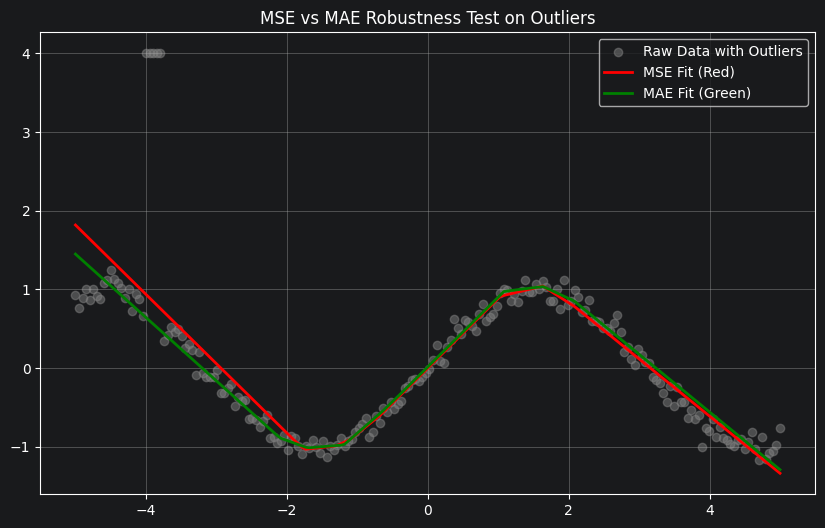

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ================= 步骤 1：生成脏数据 =================
x_np = np.linspace(-5, 5, 200)
y_np = np.sin(x_np) + 0.1 * np.random.randn(200)

# 植入 5 个极端脏数据
y_np[20:25] = 4.0

x_train = torch.FloatTensor(x_np).view(-1, 1)
y_train = torch.FloatTensor(y_np).view(-1, 1)

# ================= 定义神经网络模型 =================
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.hidden = nn.Linear(1, 16)  # 隐藏层 16 个神经元
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)  # 输出层

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

def train_model(model, loss_fn, color, label, epochs=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(x_train)
        loss = loss_fn(predictions, y_train)
        loss.backward()
        optimizer.step()

    # 绘制最终预测曲线
    plt.plot(x_np, predictions.detach().numpy(), color=color, label=label, linewidth=2)

# ================= 步骤 2 & 3：训练对比 =================
plt.figure(figsize=(10, 6))
plt.scatter(x_np, y_np, color='gray', alpha=0.5, label='Raw Data with Outliers')

# 训练 MSE 模型 (红线)
model_mse = SimpleNet()
train_model(model_mse, nn.MSELoss(), color='red', label='MSE Fit (Red)')

# 训练 MAE 模型 (绿线)
model_mae = SimpleNet()
train_model(model_mae, nn.L1Loss(), color='green', label='MAE Fit (Green)')

plt.title("MSE vs MAE Robustness Test on Outliers")
plt.legend()
plt.grid(True)
plt.show()